In [ ]:
!pip install roboflow
!pip install ultralytics
from roboflow import Roboflow
rf = Roboflow(api_key="jD3E4pK4MQpahwWIUn8F")
project = rf.workspace("ml-k7bdf").project("fire-detection-sejra-vlvkw")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.6 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-Detection-1 in yolov8:: 100%|██████████| 17883/17883 [00:03<00:00, 4822.64it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

# 1. Initialize the model (T4 GPU should be active)
model = YOLO('yolov8n.pt')

# 2. Start the 50-epoch study session
results = model.train(
    data='/content/datasets/Fire-Detection-1/data.yaml',
    epochs=50,
    imgsz=640,
    device=0
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Fire-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,


0: 544x640 1 Fire, 55.9ms
Speed: 2.7ms preprocess, 55.9ms inference, 1.8ms postprocess per image at shape (1, 3, 544, 640)


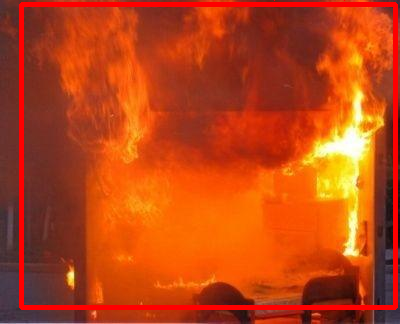

In [ ]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Load your CUSTOM trained model
model = YOLO('/content/runs/detect/train4/weights/best.pt')

def run_fire_analysis(image_path):
    frame = cv2.imread(image_path)
    h, w, _ = frame.shape
    total_area = h * w

    # Run Detection
    results = model(frame, conf=0.5)

    for r in results:
        for box in r.boxes:
            # Coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Feature: Calculate Intensity
            # Intensity = (Fire Area / Screen Area) * 100
            fire_area = (x2 - x1) * (y2 - y1)
            intensity = (fire_area / total_area) * 100

            # Feature: Danger Logic
            if intensity > 35:
                status, color = "CRITICAL: LARGE FIRE", (0, 0, 255) # Red
            elif intensity > 10:
                status, color = "WARNING: MEDIUM FIRE", (0, 165, 255) # Orange
            else:
                status, color = "LOW: SMALL FIRE", (0, 255, 0) # Green

            # Draw on the frame
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
            cv2.putText(frame, f"{status} ({intensity:.1f}%)", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2_imshow(frame)

# Usage: Run it on a test image from your dataset
run_fire_analysis('/content/datasets/Fire-Detection-1/train/images/large_-1-_jpg.rf.b68d2655070a64a17ce5b2537fb1ff5b.jpg')